In [ ]:
# ====================================================================
# PHAN 2: TONG QUAN VE MANG XA HOI (NETWORK OVERVIEW)
# ====================================================================
# Dataset: Facebook Social Circles from Stanford SNAP
# Source: https://snap.stanford.edu/data/
# Citation: J. McAuley & J. Leskovec. NIPS 2012
# ====================================================================

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
import os
import json
warnings.filterwarnings('ignore')

# Cau hinh matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Tải Dữ Liệu Thực Tế

**Dataset**: Facebook Social Circles (Stanford SNAP)  
**Kích thước**: 4,039 nodes | 88,234 edges  
**Trích dẫn**: Xem file `data/CITATION.txt`

In [ ]:
# Load network data tu Stanford SNAP
data_dir = '../data'
gexf_file = f'{data_dir}/social_network.gexf'
citation_file = f'{data_dir}/CITATION.txt'

print("Loading Facebook Social Circles dataset...")
print("="*70)

if os.path.exists(gexf_file):
    G = nx.read_gexf(gexf_file)
    G = nx.convert_node_labels_to_integers(G)
    print("Dataset loaded successfully!")
else:
    raise FileNotFoundError(f"File not found: {gexf_file}\nRun: python ../scripts/data_collection.py")

# Load dataset info
if os.path.exists(f'{data_dir}/dataset_info.json'):
    with open(f'{data_dir}/dataset_info.json', 'r', encoding='utf-8') as f:
        dataset_info = json.load(f)
    print(f"\nDataset: {dataset_info['dataset_name']}")
    print(f"Source: {dataset_info['source']}")
    print(f"Citation: {dataset_info['citation']}")

if os.path.exists(citation_file):
    print(f"\nFull citation info: {citation_file}")

n_nodes = G.number_of_nodes()
m_edges = G.number_of_edges()

print("\n" + "="*70)
print(f"Network: {n_nodes:,} nodes, {m_edges:,} edges")
print("="*70)

Loading Facebook Social Circles dataset...
✓ Dataset loaded successfully!

Dataset: Facebook Social Circles
Source: Stanford Network Analysis Project (SNAP)
Citation: J. McAuley and J. Leskovec. Learning to Discover Social Circles in Ego Networks. NIPS, 2012.

Full citation info: ../data/CITATION.txt

Network: 4,039 nodes, 88,234 edges
✓ Dataset loaded successfully!

Dataset: Facebook Social Circles
Source: Stanford Network Analysis Project (SNAP)
Citation: J. McAuley and J. Leskovec. Learning to Discover Social Circles in Ego Networks. NIPS, 2012.

Full citation info: ../data/CITATION.txt

Network: 4,039 nodes, 88,234 edges


## 2. Thông Tin Cơ Bản Về Mạng

In [ ]:
# Thong tin co ban
print("="*70)
print("THONG TIN CO BAN VE MANG XA HOI")
print("="*70)

print(f"\n1. Loai do thi: {'Co huong (Directed)' if G.is_directed() else 'Vo huong (Undirected)'}")
print(f"2. So nodes (nguoi dung): {n_nodes:,}")
print(f"3. So edges (ket noi): {m_edges:,}")
print(f"4. Mat do (Density): {nx.density(G):.6f}")

# Kiem tra tinh lien thong
is_connected = nx.is_connected(G)
print(f"5. Lien thong: {'Co' if is_connected else 'Khong'}")

if not is_connected:
    components = list(nx.connected_components(G))
    print(f"   - So thanh phan lien thong: {len(components)}")
    largest_cc = max(components, key=len)
    print(f"   - Thanh phan lon nhat: {len(largest_cc):,} nodes ({len(largest_cc)/n_nodes*100:.1f}%)")
    
print("="*70)

THÔNG TIN CƠ BẢN VỀ MẠNG XÃ HỘI

1. Loại đồ thị: Vô hướng (Undirected)
2. Số nodes (người dùng): 4,039
3. Số edges (kết nối): 88,234
4. Mật độ (Density): 0.010820
5. Liên thông: Có



THUỘC TÍNH NÚT

Phân phối loại nút:
  Unknown: 4039 (100.0%)


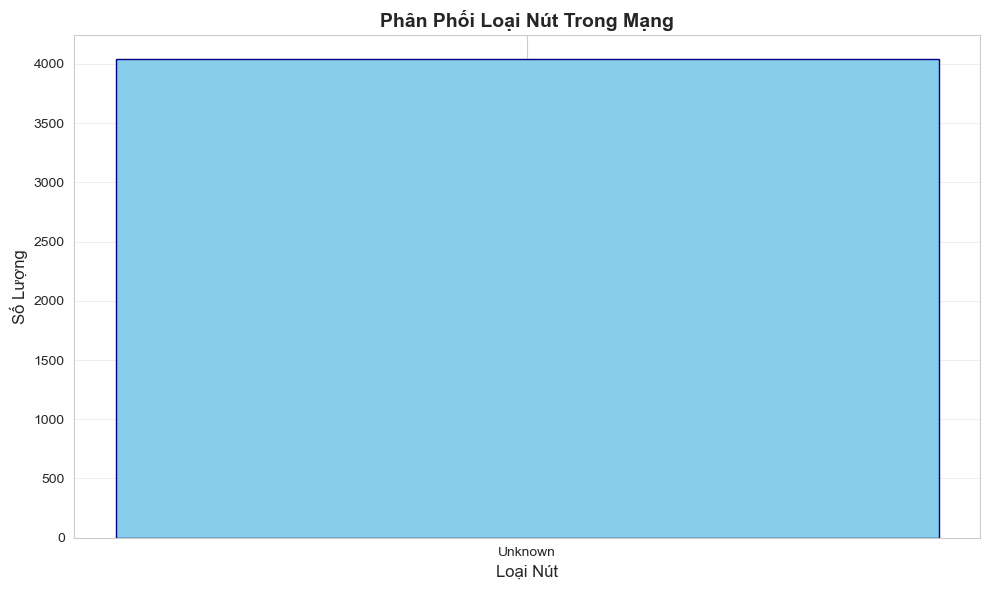

In [ ]:
# Thong ke thuoc tinh nut
print("\n" + "=" * 60)
print("THUOC TINH NUT")
print("=" * 60)

# Lay cac thuoc tinh nut
node_types = [G.nodes[node].get('type', 'Unknown') for node in G.nodes()]
type_counts = Counter(node_types)

print("\nPhan phoi loai nut:")
for node_type, count in type_counts.items():
    print(f"  {node_type}: {count} ({count/len(node_types)*100:.1f}%)")

# Ve bieu do
plt.figure(figsize=(10, 6))
plt.bar(type_counts.keys(), type_counts.values(), color='skyblue', edgecolor='navy')
plt.xlabel('Loai Nut', fontsize=12)
plt.ylabel('So Luong', fontsize=12)
plt.title('Phan Phoi Loai Nut Trong Mang', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Đường Kính và Bán Kính

In [46]:
# Tinh duong kinh va ban kinh cho thanh phan lien thong lon nhat
print("\n" + "=" * 60)
print("DUONG KINH VA BAN KINH")
print("=" * 60)

if nx.is_connected(G):
    G_largest = G
else:
    # Lay thanh phan lien thong lon nhat
    largest_cc = max(nx.connected_components(G), key=len)
    G_largest = G.subgraph(largest_cc).copy()
    print(f"\nPhan tich tren thanh phan lien thong lon nhat ({len(largest_cc)} nut)")

try:
    diameter = nx.diameter(G_largest)
    radius = nx.radius(G_largest)
    print(f"\nDuong kinh (Diameter): {diameter}")
    print(f"Ban kinh (Radius): {radius}")
    print(f"\nGiai thich:")
    print(f"  - Duong kinh {diameter} nghia la khoang cach xa nhat giua 2 nut bat ky la {diameter} buoc")
    print(f"  - Ban kinh {radius} nghia la ton tai nut trung tam co khoang cach xa nhat den nut khac la {radius} buoc")
except:
    print("\nKhong the tinh duong kinh/ban kinh (do thi khong lien thong hoac qua lon)")


DUONG KINH VA BAN KINH

Duong kinh (Diameter): 8
Ban kinh (Radius): 4

Giai thich:
  - Duong kinh 8 nghia la khoang cach xa nhat giua 2 nut bat ky la 8 buoc
  - Ban kinh 4 nghia la ton tai nut trung tam co khoang cach xa nhat den nut khac la 4 buoc

Duong kinh (Diameter): 8
Ban kinh (Radius): 4

Giai thich:
  - Duong kinh 8 nghia la khoang cach xa nhat giua 2 nut bat ky la 8 buoc
  - Ban kinh 4 nghia la ton tai nut trung tam co khoang cach xa nhat den nut khac la 4 buoc


## 4. Hệ Số Phân Cụm (Clustering Coefficient)

In [ ]:
# Tinh he so phan cum
print("\n" + "=" * 60)
print("HE SO PHAN CUM")
print("=" * 60)

# He so phan cum toan cuc
global_clustering = nx.transitivity(G)
print(f"\nHe so phan cum toan cuc (Global): {global_clustering:.4f}")

# He so phan cum trung binh cuc bo
avg_clustering = nx.average_clustering(G)
print(f"He so phan cum trung binh cuc bo (Average Local): {avg_clustering:.4f}")

# Tinh he so phan cum cho tung nut
local_clustering = nx.clustering(G)
clustering_values = list(local_clustering.values())

print(f"\nThong ke he so phan cum cuc bo:")
print(f"  Min: {min(clustering_values):.4f}")
print(f"  Max: {max(clustering_values):.4f}")
print(f"  Mean: {np.mean(clustering_values):.4f}")
print(f"  Median: {np.median(clustering_values):.4f}")
print(f"  Std: {np.std(clustering_values):.4f}")


HỆ SỐ PHÂN CỤM

Hệ số phân cụm toàn cục (Global): 0.5192

Hệ số phân cụm toàn cục (Global): 0.5192
Hệ số phân cụm trung bình cục bộ (Average Local): 0.6055
Hệ số phân cụm trung bình cục bộ (Average Local): 0.6055

Thống kê hệ số phân cụm cục bộ:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.6055
  Median: 0.6000
  Std: 0.2144

Thống kê hệ số phân cụm cục bộ:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.6055
  Median: 0.6000
  Std: 0.2144


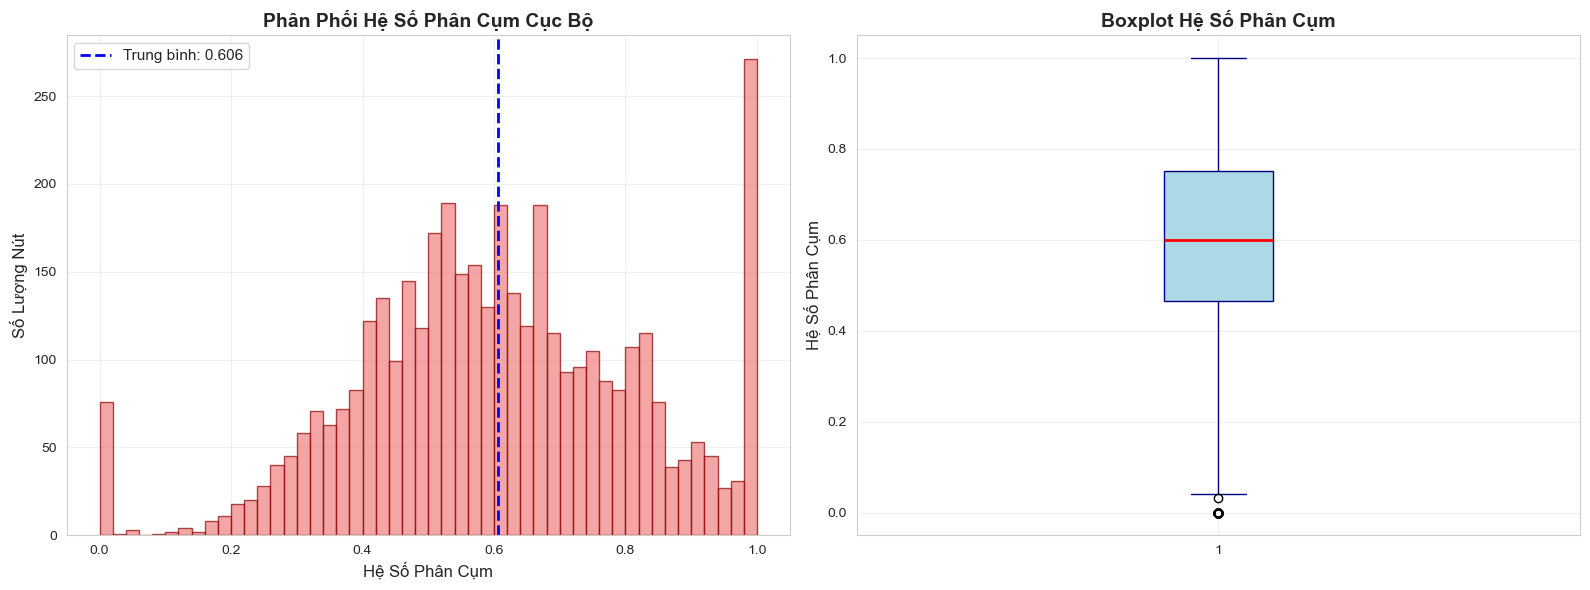


➤ Giải thích:
  Hệ số phân cụm cao (0.606) cho thấy mạng có xu hướng hình thành các nhóm/cụm chặt chẽ.


In [ ]:
# Ve histogram cua he so phan cum
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(clustering_values, bins=50, color='lightcoral', edgecolor='darkred', alpha=0.7)
axes[0].axvline(avg_clustering, color='blue', linestyle='--', linewidth=2, label=f'Trung binh: {avg_clustering:.3f}')
axes[0].set_xlabel('He So Phan Cum', fontsize=12)
axes[0].set_ylabel('So Luong Nut', fontsize=12)
axes[0].set_title('Phan Phoi He So Phan Cum Cuc Bo', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(clustering_values, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('He So Phan Cum', fontsize=12)
axes[1].set_title('Boxplot He So Phan Cum', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGiai thich:")
print(f"  He so phan cum cao ({avg_clustering:.3f}) cho thay mang co xu huong hinh thanh cac nhom/cum chat che.")

## 5. Độ Dài Đường Đi Trung Bình

In [47]:
# Tinh do dai duong di trung binh
print("\n" + "=" * 60)
print("DO DAI DUONG DI TRUNG BINH")
print("=" * 60)

if nx.is_connected(G_largest):
    avg_shortest_path = nx.average_shortest_path_length(G_largest)
    print(f"\nDo dai duong di trung binh: {avg_shortest_path:.4f}")
    print(f"\nGiai thich:")
    print(f"  Trung binh can {avg_shortest_path:.2f} buoc de di tu mot nut den nut khac.")
    print(f"  Day la dac trung cua mang 'the gioi nho' (small-world network).")
else:
    print("\nDo thi khong lien thong, tinh cho thanh phan lon nhat...")
    avg_shortest_path = nx.average_shortest_path_length(G_largest)
    print(f"Do dai duong di trung binh (thanh phan lon nhat): {avg_shortest_path:.4f}")


DO DAI DUONG DI TRUNG BINH

Do dai duong di trung binh: 3.6925

Giai thich:
  Trung binh can 3.69 buoc de di tu mot nut den nut khac.
  Day la dac trung cua mang 'the gioi nho' (small-world network).

Do dai duong di trung binh: 3.6925

Giai thich:
  Trung binh can 3.69 buoc de di tu mot nut den nut khac.
  Day la dac trung cua mang 'the gioi nho' (small-world network).



Tính toán phân phối độ dài đường đi...


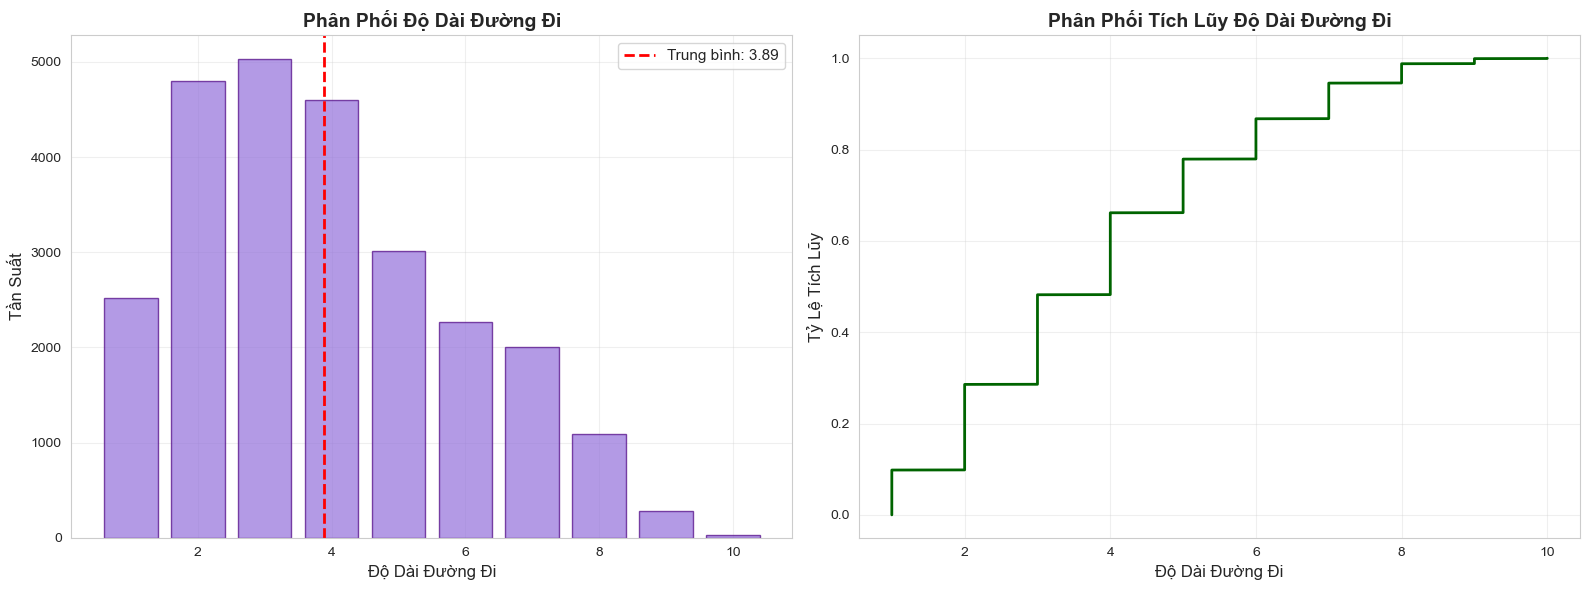


Thống kê độ dài đường đi:
  Min: 1
  Max: 10
  Mean: 3.8940
  Median: 4.0000


In [ ]:
# Tinh va ve phan phoi do dai duong di
print("\nTinh toan phan phoi do dai duong di...")

# Lay mau neu do thi qua lon
if len(G_largest) > 500:
    sample_nodes = np.random.choice(list(G_largest.nodes()), size=500, replace=False)
    G_sample = G_largest.subgraph(sample_nodes)
else:
    G_sample = G_largest

# Tinh do dai duong di ngan nhat giua tat ca cac cap nut
path_lengths = []
for source in G_sample.nodes():
    lengths = nx.single_source_shortest_path_length(G_sample, source)
    path_lengths.extend([length for target, length in lengths.items() if source != target])

path_length_counts = Counter(path_lengths)

# Ve bieu do
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].bar(path_length_counts.keys(), path_length_counts.values(), 
            color='mediumpurple', edgecolor='indigo', alpha=0.7)
axes[0].axvline(np.mean(path_lengths), color='red', linestyle='--', linewidth=2, 
                label=f'Trung binh: {np.mean(path_lengths):.2f}')
axes[0].set_xlabel('Do Dai Duong Di', fontsize=12)
axes[0].set_ylabel('Tan Suat', fontsize=12)
axes[0].set_title('Phan Phoi Do Dai Duong Di', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Cumulative distribution
sorted_lengths = sorted(path_lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, cumulative, color='darkgreen', linewidth=2)
axes[1].set_xlabel('Do Dai Duong Di', fontsize=12)
axes[1].set_ylabel('Ty Le Tich Luy', fontsize=12)
axes[1].set_title('Phan Phoi Tich Luy Do Dai Duong Di', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThong ke do dai duong di:")
print(f"  Min: {min(path_lengths)}")
print(f"  Max: {max(path_lengths)}")
print(f"  Mean: {np.mean(path_lengths):.4f}")
print(f"  Median: {np.median(path_lengths):.4f}")

## 6. Phân Phối Bậc (Degree Distribution)

In [ ]:
# Tinh phan phoi bac
print("\n" + "=" * 60)
print("PHAN PHOI BAC")
print("=" * 60)

degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)

print(f"\nThong ke bac:")
print(f"  Bac trung binh: {np.mean(degrees):.2f}")
print(f"  Bac trung vi: {np.median(degrees):.2f}")
print(f"  Bac nho nhat: {min(degrees)}")
print(f"  Bac lon nhat: {max(degrees)}")
print(f"  Do lech chuan: {np.std(degrees):.2f}")

# Top 10 nut co bac cao nhat
top_degree_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 nut co bac cao nhat:")
for i, (node, degree) in enumerate(top_degree_nodes, 1):
    node_name = G.nodes[node].get('name', f'Node_{node}')
    print(f"  {i}. {node_name}: {degree} ket noi")


PHÂN PHỐI BẬC

Thống kê bậc:
  Bậc trung bình: 43.69
  Bậc trung vị: 25.00
  Bậc nhỏ nhất: 1
  Bậc lớn nhất: 1045
  Độ lệch chuẩn: 52.41

Top 10 nút có bậc cao nhất:
  1. User_107: 1045 kết nối
  2. User_1684: 792 kết nối
  3. User_1912: 755 kết nối
  4. User_3437: 547 kết nối
  5. User_0: 347 kết nối
  6. User_2543: 294 kết nối
  7. User_2347: 291 kết nối
  8. User_1888: 254 kết nối
  9. User_1800: 245 kết nối
  10. User_1663: 235 kết nối


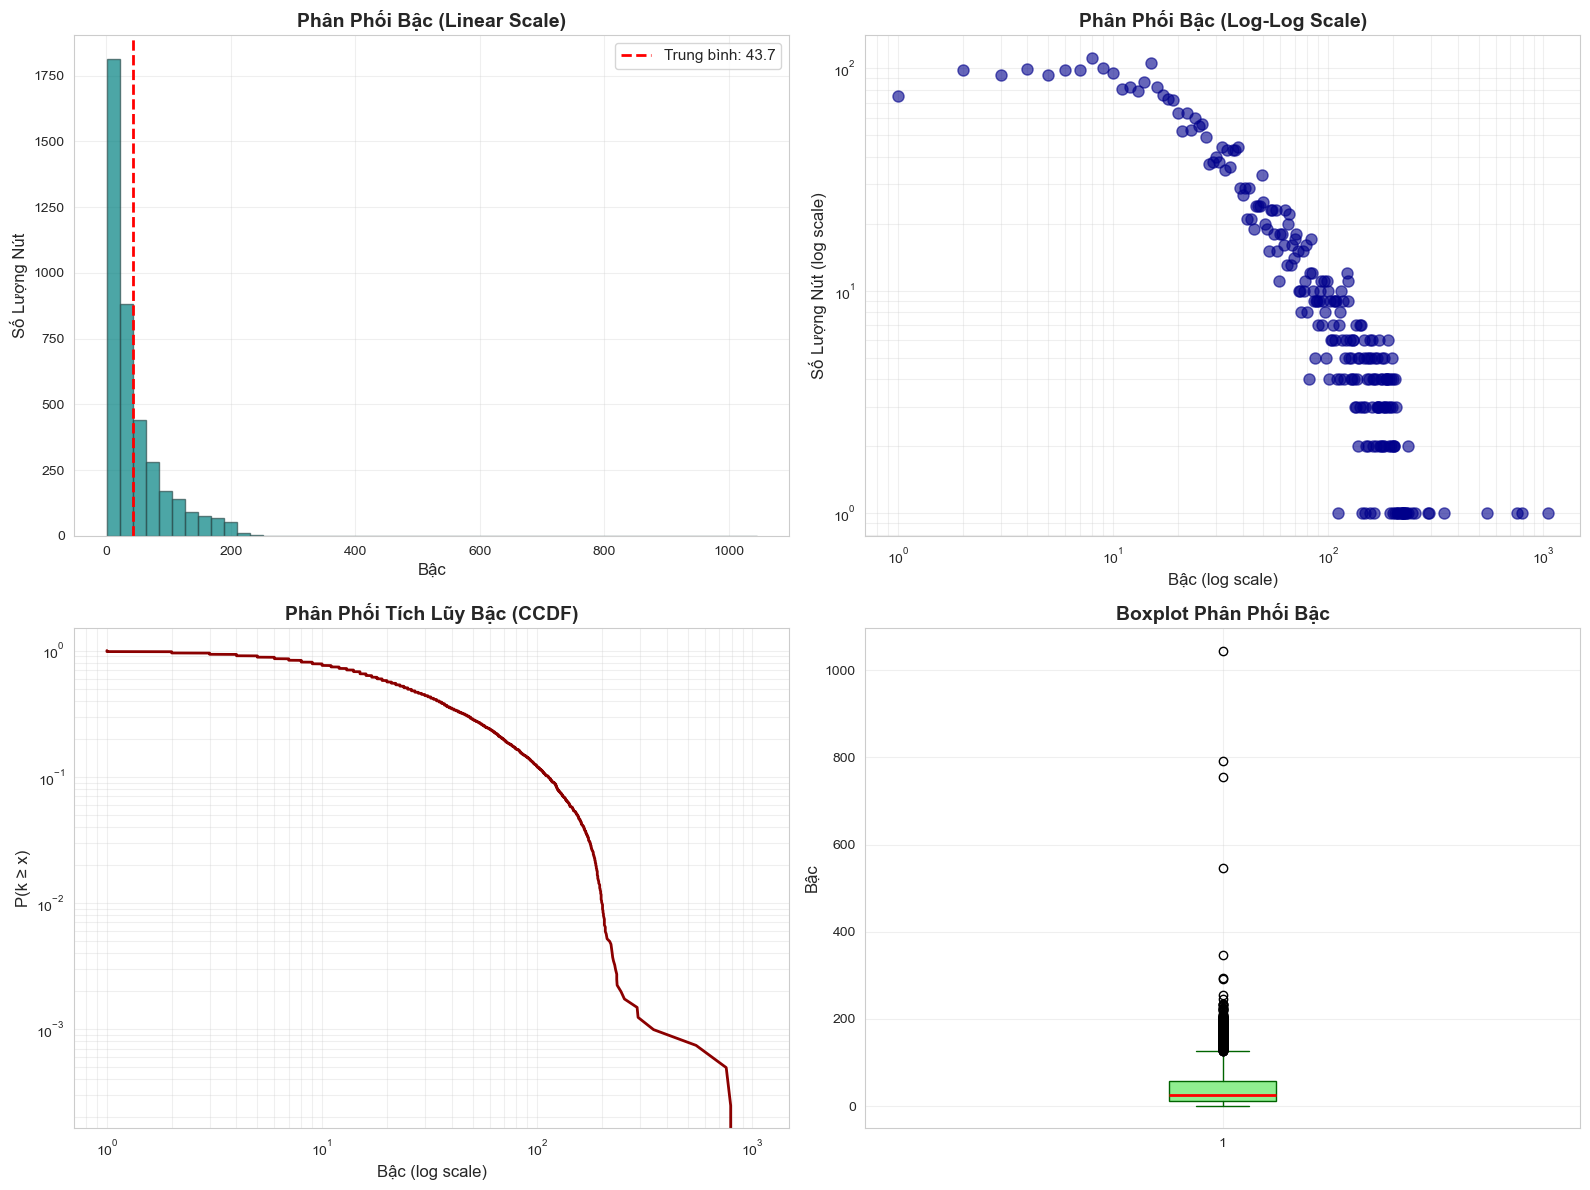

In [ ]:
# Ve phan phoi bac
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram - Linear scale
axes[0, 0].hist(degrees, bins=50, color='teal', edgecolor='darkslategray', alpha=0.7)
axes[0, 0].axvline(np.mean(degrees), color='red', linestyle='--', linewidth=2, 
                   label=f'Trung binh: {np.mean(degrees):.1f}')
axes[0, 0].set_xlabel('Bac', fontsize=12)
axes[0, 0].set_ylabel('So Luong Nut', fontsize=12)
axes[0, 0].set_title('Phan Phoi Bac (Linear Scale)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)

# 2. Log-log plot
degrees_sorted = sorted(degree_counts.items())
x_deg = [d for d, c in degrees_sorted]
y_count = [c for d, c in degrees_sorted]

axes[0, 1].loglog(x_deg, y_count, 'o', color='darkblue', markersize=8, alpha=0.6)
axes[0, 1].set_xlabel('Bac (log scale)', fontsize=12)
axes[0, 1].set_ylabel('So Luong Nut (log scale)', fontsize=12)
axes[0, 1].set_title('Phan Phoi Bac (Log-Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3, which='both')

# 3. Cumulative distribution
sorted_degrees = np.sort(degrees)
cumulative = 1 - np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
axes[1, 0].loglog(sorted_degrees, cumulative, color='darkred', linewidth=2)
axes[1, 0].set_xlabel('Bac (log scale)', fontsize=12)
axes[1, 0].set_ylabel('P(k >= x)', fontsize=12)
axes[1, 0].set_title('Phan Phoi Tich Luy Bac (CCDF)', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3, which='both')

# 4. Boxplot
axes[1, 1].boxplot(degrees, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                   whiskerprops=dict(color='darkgreen'),
                   capprops=dict(color='darkgreen'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Bac', fontsize=12)
axes[1, 1].set_title('Boxplot Phan Phoi Bac', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Mô Hình Hóa Phân Phối Bậc Bằng Hồi Quy

In [ ]:
# Kiem tra xem phan phoi bac co tuan theo luat luy thua (Power Law) khong
print("\n" + "=" * 60)
print("MO HINH HOA PHAN PHOI BAC")
print("=" * 60)

# Chuan bi du lieu cho hoi quy
degrees_sorted = sorted(degree_counts.items())
x_deg = np.array([d for d, c in degrees_sorted if d > 0])  # Bo qua bac 0
y_count = np.array([c for d, c in degrees_sorted if d > 0])

# Loai bo cac gia tri 0 trong y_count de tranh loi log
mask = y_count > 0
x_deg_filtered = x_deg[mask]
y_count_filtered = y_count[mask]

# Chuyen sang log scale
log_x = np.log10(x_deg_filtered)
log_y = np.log10(y_count_filtered)

# Hoi quy tuyen tinh trong khong gian log-log
# log(y) = a + b * log(x) => y = 10^a * x^b (Power law)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)

print(f"\nKet qua hoi quy Power Law: P(k) proportional to k^gamma")
print(f"  He so gamma: {-slope:.3f}")
print(f"  He so tuong quan R2: {r_value**2:.4f}")
print(f"  P-value: {p_value:.4e}")

if r_value**2 > 0.8:
    print(f"\nKet luan: Phan phoi bac co xu huong tuan theo luat luy thua (Power Law)")
    print(f"  voi he so gamma xap xi {-slope:.2f}, dac trung cua mang khong ty le (scale-free network).")
else:
    print(f"\nKet luan: Phan phoi bac khong hoan toan tuan theo luat luy thua.")
    print(f"  Co the la mang ngau nhien hoac mang the gioi nho.")


MÔ HÌNH HÓA PHÂN PHỐI BẬC

Kết quả hồi quy Power Law: P(k) ∝ k^γ
  Hệ số γ (gamma): 1.180
  Hệ số tương quan R²: 0.8092
  P-value: 6.9426e-83

➤ Kết luận: Phân phối bậc có xu hướng tuân theo luật lũy thừa (Power Law)
  với hệ số γ ≈ 1.18, đặc trưng của mạng không tỷ lệ (scale-free network).


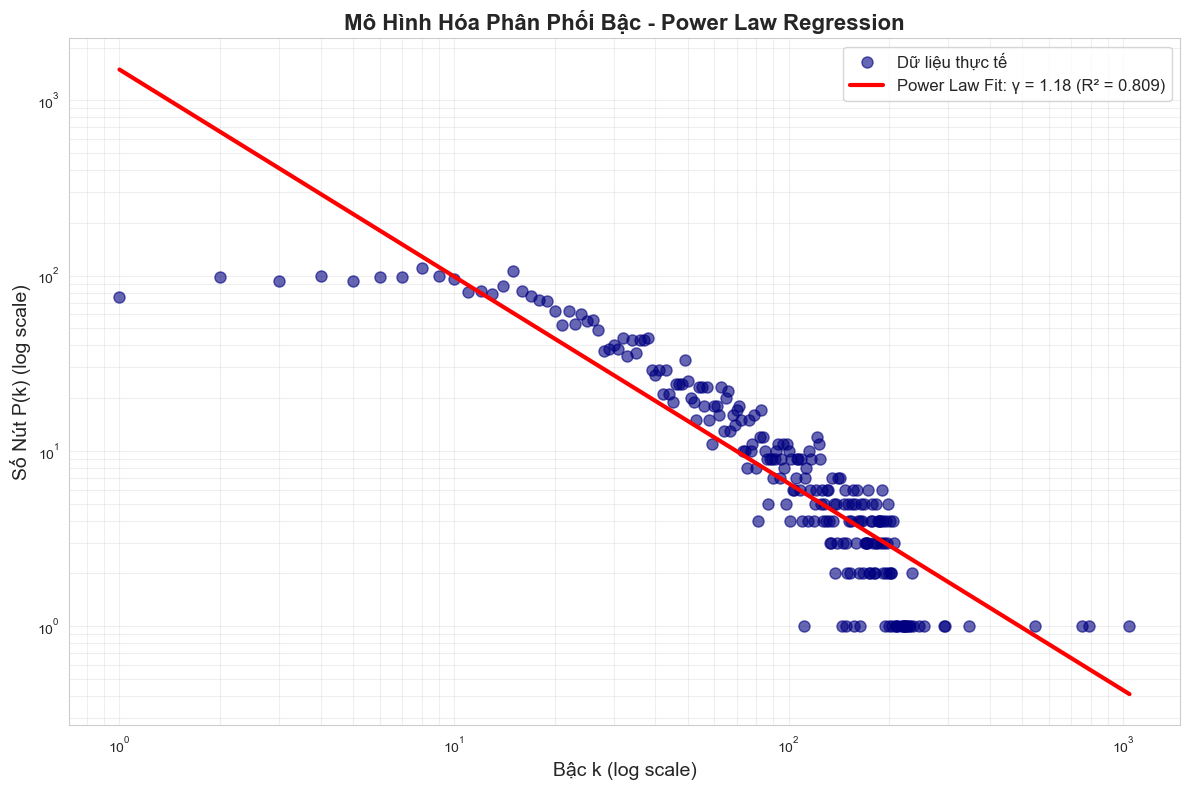

In [ ]:
# Ve bieu do hoi quy
plt.figure(figsize=(12, 8))

# Du lieu thuc
plt.loglog(x_deg_filtered, y_count_filtered, 'o', color='navy', 
           markersize=8, alpha=0.6, label='Du lieu thuc te')

# Duong hoi quy
y_pred = 10**(intercept + slope * log_x)
plt.loglog(x_deg_filtered, y_pred, '-', color='red', linewidth=3, 
           label=f'Power Law Fit: gamma = {-slope:.2f} (R2 = {r_value**2:.3f})')

plt.xlabel('Bac k (log scale)', fontsize=14)
plt.ylabel('So Nut P(k) (log scale)', fontsize=14)
plt.title('Mo Hinh Hoa Phan Phoi Bac - Power Law Regression', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 8. Xuất Dữ Liệu Cho Gephi

In [ ]:
# Xuat file GEXF cho Gephi
output_file = '../data/network_for_gephi.gexf'
nx.write_gexf(G, output_file)
print(f"\nDa xuat do thi ra file: {output_file}")
print("Ban co the mo file nay trong Gephi de truc quan hoa mang.")

# Xuat them dinh dang CSV
# Nodes
nodes_data = []
for node in G.nodes():
    nodes_data.append({
        'id': node,
        'label': G.nodes[node].get('name', f'Node_{node}'),
        'type': G.nodes[node].get('type', 'Unknown'),
        'degree': G.degree(node)
    })
nodes_df = pd.DataFrame(nodes_data)
nodes_df.to_csv('../data/nodes.csv', index=False, encoding='utf-8-sig')

# Edges
edges_data = []
for edge in G.edges():
    edges_data.append({
        'source': edge[0],
        'target': edge[1],
        'weight': G.edges[edge].get('weight', 1)
    })
edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('../data/edges.csv', index=False, encoding='utf-8-sig')

print("\nDa xuat nodes.csv va edges.csv de su dung cho cac cong cu khac.")


Đã xuất đồ thị ra file: ../data/network_for_gephi.gexf
Bạn có thể mở file này trong Gephi để trực quan hóa mạng.

Đã xuất nodes.csv và edges.csv để sử dụng cho các công cụ khác.

Đã xuất nodes.csv và edges.csv để sử dụng cho các công cụ khác.
